In [9]:
import pandas as pd

df = pd.read_csv('auto-insurance-claims-data(in).csv')
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,10/17/2014,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,6/27/2006,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,9/6/2000,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,5/25/1990,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,6/6/2014,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [10]:
df.columns.tolist()

['months_as_customer',
 'age',
 'policy_number',
 'policy_bind_date',
 'policy_state',
 'policy_csl',
 'policy_deductable',
 'policy_annual_premium',
 'umbrella_limit',
 'insured_zip',
 'insured_sex',
 'insured_education_level',
 'insured_occupation',
 'insured_hobbies',
 'insured_relationship',
 'capital-gains',
 'capital-loss',
 'incident_date',
 'incident_type',
 'collision_type',
 'incident_severity',
 'authorities_contacted',
 'incident_state',
 'incident_city',
 'incident_location',
 'incident_hour_of_the_day',
 'number_of_vehicles_involved',
 'property_damage',
 'bodily_injuries',
 'witnesses',
 'police_report_available',
 'total_claim_amount',
 'injury_claim',
 'property_claim',
 'vehicle_claim',
 'auto_make',
 'auto_model',
 'auto_year',
 'fraud_reported',
 '_c39']

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [12]:
# Drop the empty junk column (only if it still exists)
if '_c39' in df.columns:
  df = df.drop(columns=['_c39'])

# Replace '?' placeholders with actual NaN so pandas recognizes them as missing
df = df.replace('?', pd.NA)

# Check how much missing data we now have
df.isnull().sum()[df.isnull().sum() > 0]

,0
collision_type,178
authorities_contacted,91
property_damage,360
police_report_available,343


In [13]:
# Fill missing categorical values with "Unknown" - preserves all 1000 rows
cols_to_fill = ['collision_type', 'authorities_contacted', 'property_damage', 'police_report_available']
df[cols_to_fill] = df[cols_to_fill].fillna('Unknown')

#Confirm no missing values remain
df.isnull().sum().sum()

np.int64(0)

In [14]:
# Cnvert date column properly
df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'])

# 1. Claim frequency by incident type
claim_freq = df['incident_type'].value_counts()
print("Claim frequency by incident type:\n", claim_freq)

# 2. Average claim amount by incident severity
avg_claim = df.groupby('incident_severity')['total_claim_amount'].mean().sort_values(ascending=False)
print("\nAverage claim amount by severity:\n", avg_claim)

# 3. Loss ratio by policy state (claims paid vs premium collected)
loss_ratio = df.groupby('policy_state').apply(
    lambda x: x['total_claim_amount'].sum() / x['policy_annual_premium'].sum()
)
print("\nLoss ratio by state:\n, loss_ratio)")

Claim frequency by incident type:
 incident_type
Multi-vehicle Collision     419
Single Vehicle Collision    403
Vehicle Theft                94
Parked Car                   84
Name: count, dtype: int64

Average claim amount by severity:
 incident_severity
Major Damage      64067.173913
Total Loss        62081.214286
Minor Damage      48642.683616
Trivial Damage     5301.666667
Name: total_claim_amount, dtype: float64

Loss ratio by state:
, loss_ratio)


/tmp/ipykernel_591/3260850155.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  loss_ratio = df.groupby('policy_state').apply(


In [15]:
# Cleaner way to avoid the depreciation warning
loss_ratio = df.groupby('policy_state').apply(
    lambda x: x['total_claim_amount'].sum() / x['policy_annual_premium'].sum(),
    include_groups=False
)
print("Loss ratio by state:\n", loss_ratio)

Loss ratio by state:
 policy_state
IL    42.169559
IN    42.223356
OH    41.626166
dtype: float64


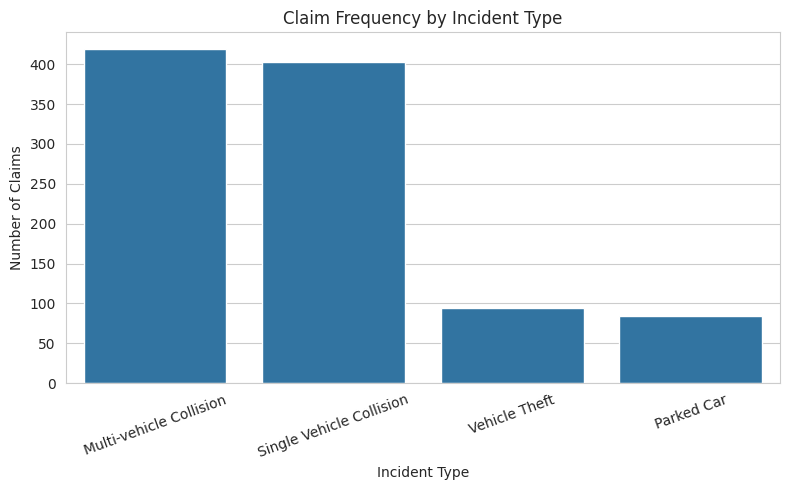

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Chart 1: Claim frequency by incident type
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='incident_type', order=df['incident_type'].value_counts().index)
plt.title('Claim Frequency by Incident Type')
plt.xlabel('Incident Type')
plt.ylabel('Number of Claims')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

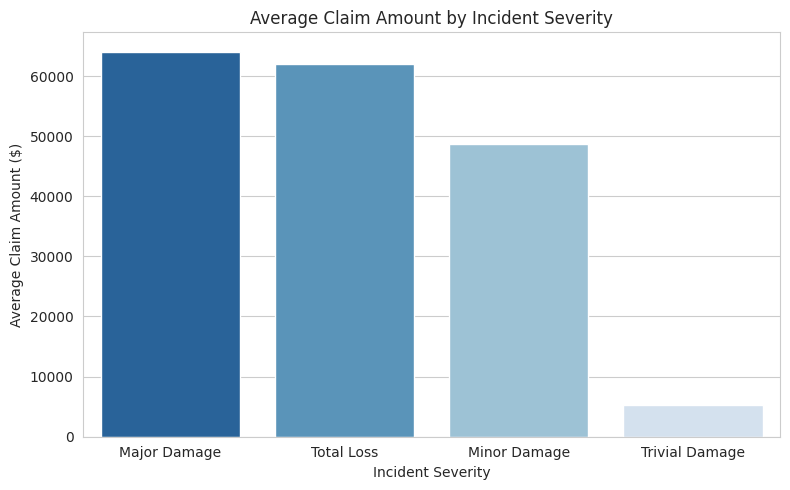

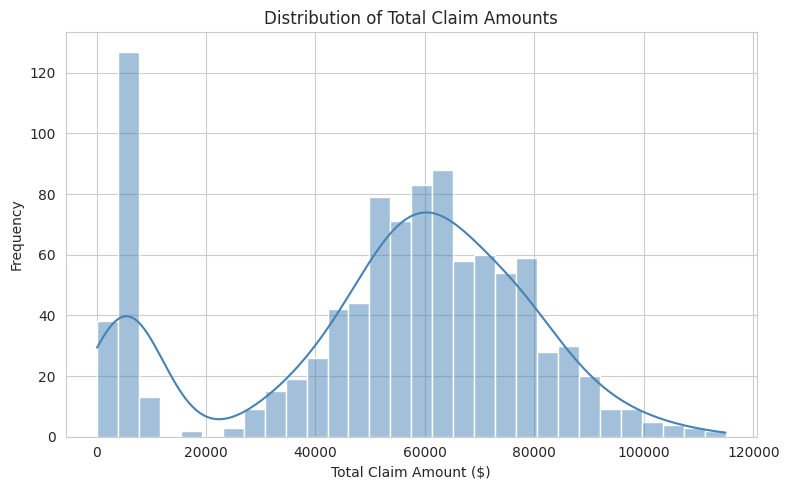

In [17]:
# Chart 2: Average claim amount by severity
plt.figure(figsize=(8,5))
avg_claim_sorted = df.groupby('incident_severity')['total_claim_amount'].mean().sort_values(ascending=False)
sns.barplot(x=avg_claim_sorted.index, y= avg_claim_sorted.values, hue=avg_claim_sorted.index, palette='Blues_r', legend=False)
plt.title('Average Claim Amount by Incident Severity')
plt.xlabel('Incident Severity')
plt.ylabel('Average Claim Amount ($)')
plt.tight_layout()
plt.show()

# Chart 3: Claim amount distrubution (helps spot outliners)
plt.figure(figsize=(8,5))
sns.histplot(df['total_claim_amount'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Total Claim Amounts')
plt.xlabel('Total Claim Amount ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [18]:
df['fraud_reported'].value_counts()

,count
fraud_reported,
N,753
Y,247


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

features= ['months_as_customer', 'age', 'policy_annual_premium',
           'total_claim_amount', 'incident_severity', 'insured_hobbies',
           'number_of_vehicles_involved', 'witnesses', 'police_report_available']

X = df[features].copy()
y = df['fraud_reported'].map({'Y': 1, 'N': 0})

categorical_cols = X.select_dtypes(include='object').columns
le = LabelEncoder()
for col in categorical_cols:
  X[col] = le.fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])


Training rows: 800
Testing rows: 200


In [24]:
# Fit the logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate performance
print("Accuuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuuracy: 0.755

Confusion Matrix:
 [[137  14]
 [ 35  14]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.91      0.85       151
           1       0.50      0.29      0.36        49

    accuracy                           0.76       200
   macro avg       0.65      0.60      0.61       200
weighted avg       0.72      0.76      0.73       200



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Re-fit the model on scaled data
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusionMatrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.78

ConfusionMatrix:
 [[137  14]
 [ 30  19]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.91      0.86       151
           1       0.58      0.39      0.46        49

    accuracy                           0.78       200
   macro avg       0.70      0.65      0.66       200
weighted avg       0.76      0.78      0.76       200

